In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn import linear_model

In [ ]:
def getSample(x):
  y = (100 * (x**2)) + 10*x + 1
  return y

In [ ]:
def drawSamples(x):
  y = np.zeros(len(x))
  for i in range(len(x)):
    y[i] = getSample(x[i]) + np.random.normal(0, 0.5, 1)[0]
  return y

In [ ]:
true_count = 10000
x_true = np.linspace(0, 5, true_count)
y_true = drawSamples(x_true)

In [ ]:
def train(x_train, y_train):
  m = 0
  c = np.average(y_train)
  return m, c

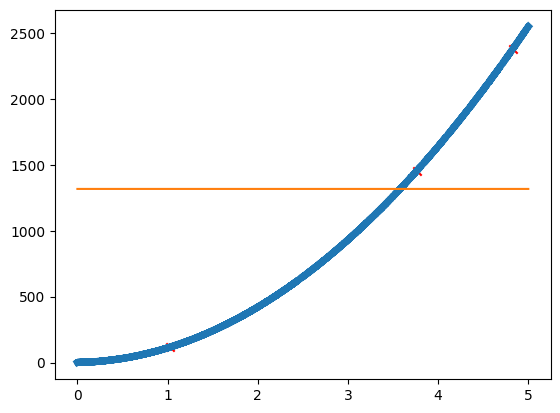

In [ ]:
n = 3
x_train = np.random.uniform(0, 5, n)
y_train = drawSamples(x_train)
m, c = train(x_train, y_train)
plt.plot(x_true, y_true, linewidth=5)
plt.scatter(x_train, y_train, color='r', marker='x')
plt.plot(x_true, c + m*x_true)
plt.show()

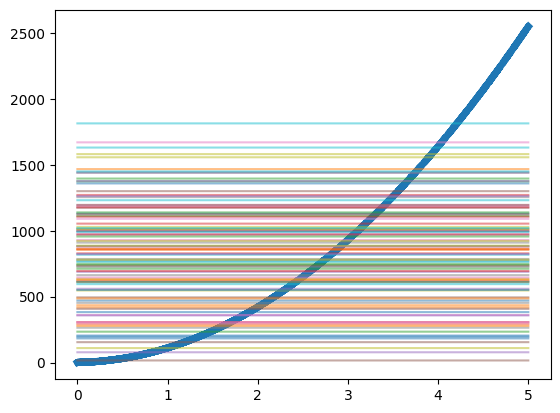

In [ ]:
runs = 100
plt.plot(x_true, y_true, linewidth=5)

m_s = np.zeros(runs)
c_s = np.zeros(runs)
m_avg = 0
c_avg = 0

for i in range(runs):
    n = 3
    x_train1 = np.random.uniform(0, 5, n)
    y_train1 = drawSamples(x_train1)
    m, c = train(x_train1, y_train1)
    m_s[i] = m
    c_s[i] = c
    m_avg += m
    c_avg += c
    plt.plot(x_true, c + m*x_true, alpha=0.5)

m_avg /= runs
c_avg /= runs

plt.show()

In [ ]:
c_avg

835.0355147110884

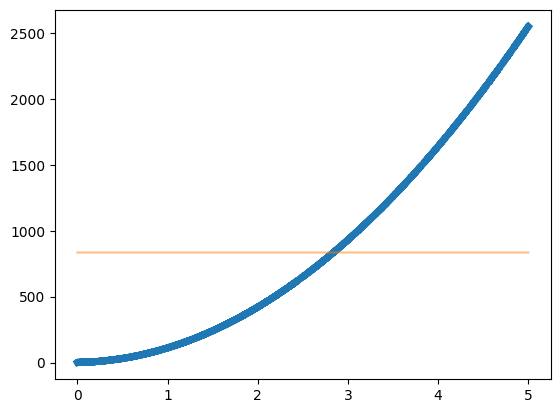

In [ ]:
plt.plot(x_true, y_true, linewidth=5)
plt.plot(x_true, c_avg + m_avg * x_true, alpha=0.5)

In [ ]:
y_pred = c_avg + m_avg * x_true
bias = np.sum((y_pred - y_true)**2) / true_count

variance = 0
for i in range(runs):
  y_curr = c_s[i] + m_s[i]*x_true
  variance += np.sum((y_curr - y_pred)**2)
variance /= (runs * true_count)

In [ ]:
bias

577300.273045709

In [ ]:
variance

164811.44103330313

In [ ]:
def train_linear(x_train, y_train):
  model = linear_model.LinearRegression()
  model.fit(x_train.reshape((-1, 1)), y_train)
  m = model.coef_[0]
  c = model.intercept_
  return m, c

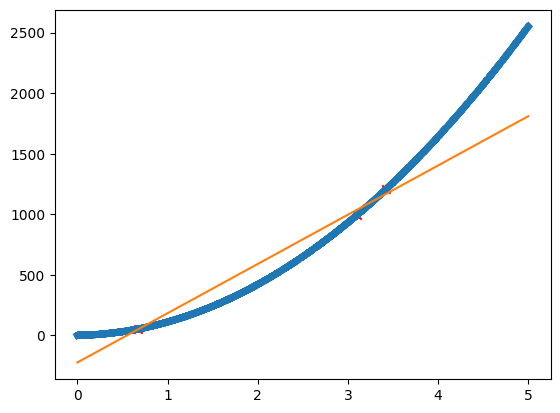

In [ ]:
n = 3
x_train = np.random.uniform(0, 5, n)
y_train = drawSamples(x_train)
m, c = train_linear(x_train, y_train)
plt.plot(x_true, y_true, linewidth=5)
plt.scatter(x_train, y_train, color='r', marker='x')
plt.plot(x_true, c + m*x_true)
plt.show()

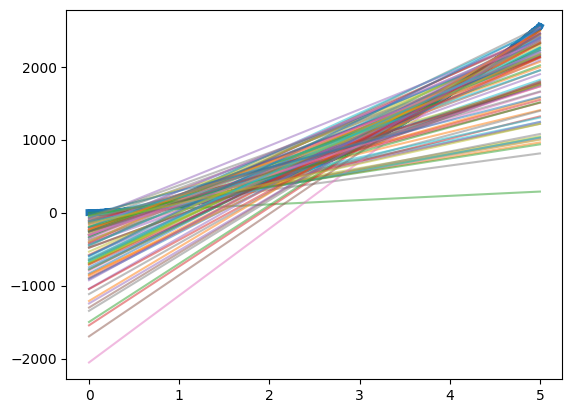

In [ ]:
runs = 100
plt.plot(x_true, y_true, linewidth=5)

m_s = np.zeros(runs)
c_s = np.zeros(runs)
m_avg = 0
c_avg = 0

for i in range(runs):
    n = 3
    x_train1 = np.random.uniform(0, 5, n)
    y_train1 = drawSamples(x_train1)
    m, c = train_linear(x_train1, y_train1)
    m_s[i] = m
    c_s[i] = c
    m_avg += m
    c_avg += c
    plt.plot(x_true, c + m*x_true, alpha=0.5)

m_avg /= runs
c_avg /= runs

plt.show()

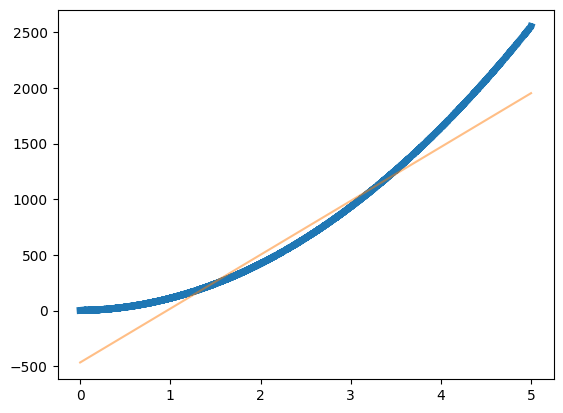

In [ ]:
plt.plot(x_true, y_true, linewidth=5)
plt.plot(x_true, c_avg + m_avg * x_true, alpha=0.5)

In [ ]:
y_pred = c_avg + m_avg * x_true
bias = np.sum((y_pred - y_true)**2) / true_count

variance = 0
for i in range(runs):
  y_curr = c_s[i] + m_s[i]*x_true
  variance += np.sum((y_curr - y_pred)**2)
variance /= (runs * true_count)

In [ ]:
bias

49761.15050891275

In [ ]:
variance

93719.07612011713

In [ ]:
def train_quad(x_train, y_train):
  coefficients = np.polyfit(x_train, y_train, 2)
  a, b, c = coefficients
  return a, b, c

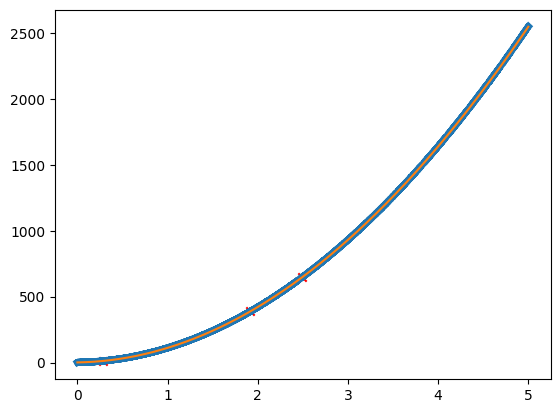

In [ ]:
n = 3
x_train = np.random.uniform(0, 5, n)
y_train = drawSamples(x_train)
a, b, c = train_quad(x_train, y_train)
plt.plot(x_true, y_true, linewidth=5)
plt.scatter(x_train, y_train, color='r', marker='x')
plt.plot(x_true, c + a*(x_true**2) + b*x_true)
plt.show()

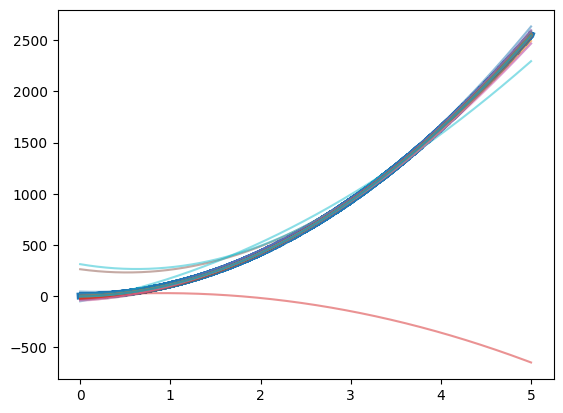

In [ ]:
runs = 100
plt.plot(x_true, y_true, linewidth=5)

a_s = np.zeros(runs)
b_s = np.zeros(runs)
c_s = np.zeros(runs)
a_avg = 0
b_avg = 0
c_avg = 0

for i in range(runs):
    n = 3
    x_train1 = np.random.uniform(0, 5, n)
    y_train1 = drawSamples(x_train1)
    a, b, c = train_quad(x_train1, y_train1)
    a_s[i] = a
    b_s[i] = b
    c_s[i] = c
    a_avg += a
    b_avg += b
    c_avg += c
    plt.plot(x_true, c + a*(x_true**2) + b*x_true, alpha=0.5)

a_avg /= runs
b_avg /= runs
c_avg /= runs

plt.show()

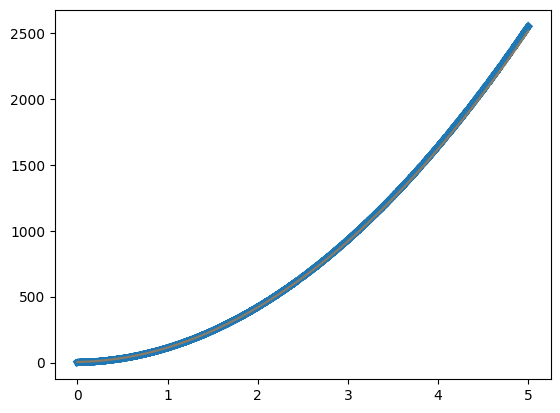

In [ ]:
plt.plot(x_true, y_true, linewidth=5)
plt.plot(x_true, c_avg + a_avg*(x_true**2) + b_avg*x_true, alpha=0.5)

In [ ]:
y_pred = c_avg + b_avg * x_true + (a_avg)*(x_true**2)
bias = np.sum((y_pred - y_true)**2) / true_count

variance = 0
for i in range(runs):
  y_curr = c_s[i] + b_s[i]*x_true + a_s[i]*(x_true**2)
  variance += np.sum((y_curr - y_pred)**2)
variance /= (runs * true_count)

In [ ]:
bias

205.13022143608345

In [ ]:
variance

19726.430519211142